# 04b — Method 3: BM25 Standalone Retrieval
## UniMatch: Arabic Student Advising Chatbot

### What is BM25?
BM25 (Best Match 25) is a probabilistic ranking function that extends TF-IDF
by incorporating document length normalization and term frequency saturation.
It is the standard baseline in information retrieval.

### BM25 vs TF-IDF
| | TF-IDF | BM25 |
|--|--------|------|
| Term frequency | Linear | Saturating (log-like) |
| Doc length normalization | No | Yes |
| Tunable parameters | No | k1, b |
| Arabic suitability | Moderate | Good |

### Dataset Setup
| Role | File | Size |
|------|------|------|
| Index | `faq_enhanced.csv` | 280 questions |
| Test queries | 4 paraphrases per question | 1,120 queries |

## Cell 1 — Install

In [1]:
!pip install -q rank-bm25 pandas matplotlib scikit-learn

## Cell 2 — Mount Drive & Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR   = '/content/drive/MyDrive/Student_chatbot/'
DATA_DIR   = os.path.join(BASE_DIR, 'data/')
RESULT_DIR = os.path.join(BASE_DIR, 'results/')
os.makedirs(RESULT_DIR, exist_ok=True)

print('Checking required files:')
path = os.path.join(DATA_DIR, 'faq_enhanced.csv')
print(f'  faq_enhanced.csv  {"✅" if os.path.exists(path) else "❌ MISSING"}')

Mounted at /content/drive
Checking required files:
  faq_enhanced.csv  ✅


## Cell 3 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from rank_bm25 import BM25Okapi

print('Imports done ✅')

Imports done ✅


## Cell 4 — Load Dataset

In [4]:
# Index = ALL questions
df_index = pd.read_csv(os.path.join(DATA_DIR, 'faq_enhanced.csv'))

# Build test queries — 4 paraphrases per question
long_rows = []
for _, row in df_index.iterrows():
    for col in ['question_alt', 'question_alt2',
                'question_alt3', 'question_alt4']:
        if col in row and pd.notna(row[col]):
            long_rows.append({
                'question': row['question'],
                'answer'  : row['answer'],
                'query'   : row[col],
            })

df_test = pd.DataFrame(long_rows)

print(f'Index  : {len(df_index)} questions ✅')
print(f'Test   : {len(df_test)} queries ✅')
display(df_test.head(4))

Index  : 280 questions ✅
Test   : 1120 queries ✅


,question,answer,query
0,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟
1,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,في أي سنة أُنشئت كلية الاقتصاد والأعمال؟
2,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,ما تاريخ تأسيس كلية الاقتصاد والأعمال؟
3,متى تأسست كلية الاقتصاد والأعمال؟,تأسست كلية الاقتصاد والأعمال عام 2007.,منذ متى تأسست كلية الاقتصاد والأعمال؟


## Cell 5 — Build BM25 Index

In [5]:
# Tokenize by whitespace — simple but effective for Arabic
tokenized_questions = [q.split() for q in df_index['question'].tolist()]
bm25 = BM25Okapi(tokenized_questions)

print(f'BM25 index built ✅')
print(f'  Indexed questions  : {len(tokenized_questions)}')
print(f'  Avg tokens/question: {np.mean([len(t) for t in tokenized_questions]):.1f}')

BM25 index built ✅
  Indexed questions  : 280
  Avg tokens/question: 6.8


## Cell 6 — Retrieval Function

In [6]:
def retrieve_bm25(query, bm25, df_index, top_k=5):
    """
    Retrieve top-k answers using BM25 ranking.
    """
    tokenized_query = query.split()
    scores          = bm25.get_scores(tokenized_query)
    top_idx         = np.argsort(scores)[::-1][:top_k]

    top_k_results = [
        (df_index.iloc[i]['question'], float(scores[i]))
        for i in top_idx
    ]

    best_idx = top_idx[0]
    return (
        df_index.iloc[best_idx]['answer'],
        float(scores[best_idx]),
        df_index.iloc[best_idx]['question'],
        top_k_results
    )

print('BM25 retrieval function defined ✅')

BM25 retrieval function defined ✅


## Cell 7 — Test on Sample Queries

In [7]:
sample_queries = df_test['query'].sample(4, random_state=42).tolist()

print('BM25 Retrieval — Sample Results')
print('='*65)
for q in sample_queries:
    answer, score, matched, _ = retrieve_bm25(q, bm25, df_index)
    print(f'\n  Query   : {q}')
    print(f'  Matched : {matched}')
    print(f'  Score   : {score:.4f}')
    print(f'  Answer  : {answer[:80]}...')
print('\n' + '='*65)

BM25 Retrieval — Sample Results

  Query   : ما معنى تأجيل الدراسة؟
  Matched : هل يمكن تأجيل التسجيل؟
  Score   : 6.4165
  Answer  : نعم، يمكن للطالب تأجيل دراسته لفصل معين وفق شروط محددة وبموافقة الجامعة....

  Query   : ما الهدف من دراسة تخصص المحاسبة والتدقيق المالي؟
  Matched : ما الغاية من دراسة تخصص المحاسبة والتدقيق المالي؟
  Score   : 18.4026
  Answer  : يهدف تخصص المحاسبة والتدقيق المالي إلى تزويد الخريجين بالمعرفة والكفاءات اللازمة...

  Query   : ما معنى الخدمات الإلكترونية في الجامعة بشكل عام؟
  Matched : ما المقصود بالخدمات الإلكترونية في الجامعة بشكل عام؟
  Score   : 16.6944
  Answer  : الخدمات الإلكترونية هي نظام متكامل تقدمه الجامعة عبر الإنترنت يهدف إلى تسهيل حيا...

  Query   : هل يمكنك الإجابة عن: ما هي خطوات التسجيل للطالب الجديد؟
  Matched : ما هي خطوات التسجيل للطالب الجديد؟
  Score   : 22.2920
  Answer  : تبدأ الخطوات بتقديم طلب الالتحاق، ثم قبول الطالب، بعدها دفع الرسوم، وأخيرًا تسجي...



## Cell 8 — Evaluation Function

In [8]:
def evaluate_bm25(df_test, bm25, df_index):
    """
    Evaluate BM25 on test queries.
    Query  = row['query']
    Target = row['answer']
    """
    correct_at1, correct_at3 = [], []
    rr_list, time_list       = [], []
    all_scores               = []

    for _, row in df_test.iterrows():
        query       = row['query']
        true_answer = row['answer']

        t_start         = time.time()
        tokenized_query = query.split()
        scores          = bm25.get_scores(tokenized_query)
        elapsed         = (time.time() - t_start) * 1000

        top5_idx = np.argsort(scores)[::-1][:5]
        top5_ans = [df_index.iloc[i]['answer'] for i in top5_idx]

        # Accuracy@1
        correct_at1.append(top5_ans[0].strip() == true_answer.strip())

        # Accuracy@3
        correct_at3.append(
            true_answer.strip() in [a.strip() for a in top5_ans[:3]])

        # MRR
        rr = 0
        for rank, ans in enumerate(top5_ans, 1):
            if ans.strip() == true_answer.strip():
                rr = 1 / rank
                break
        rr_list.append(rr)
        time_list.append(elapsed)
        all_scores.append(float(scores[top5_idx[0]]))

    return {
        'Accuracy@1'   : np.mean(correct_at1) * 100,
        'Accuracy@3'   : np.mean(correct_at3) * 100,
        'MRR'          : np.mean(rr_list),
        'Avg Score'    : np.mean(all_scores),
        'Avg Time (ms)': np.mean(time_list),
        'details'      : {
            'correct_at1': correct_at1,
            'scores'     : all_scores,
        }
    }

print('Evaluation function defined ✅')

Evaluation function defined ✅


## Cell 9 — Run Evaluation

In [9]:
print('Running BM25 evaluation...')
print(f'  Index size : {len(df_index)} questions')
print(f'  Test size  : {len(df_test)} queries')

metrics = evaluate_bm25(df_test, bm25, df_index)

print('\n' + '='*50)
print('  BM25 EVALUATION RESULTS')
print('='*50)
print(f'  Accuracy@1    : {metrics["Accuracy@1"]:.2f}%')
print(f'  Accuracy@3    : {metrics["Accuracy@3"]:.2f}%')
print(f'  MRR           : {metrics["MRR"]:.4f}')
print(f'  Avg Score     : {metrics["Avg Score"]:.4f}')
print(f'  Avg Time (ms) : {metrics["Avg Time (ms)"]:.2f}')
print(f'  Index size    : {len(df_index)}')
print(f'  Test queries  : {len(df_test)}')
print('='*50)

Running BM25 evaluation...
  Index size : 280 questions
  Test size  : 1120 queries

  BM25 EVALUATION RESULTS
  Accuracy@1    : 87.23%
  Accuracy@3    : 94.11%
  MRR           : 0.9064
  Avg Score     : 18.7159
  Avg Time (ms) : 0.49
  Index size    : 280
  Test queries  : 1120


## Cell 10 — Score Distribution Plot

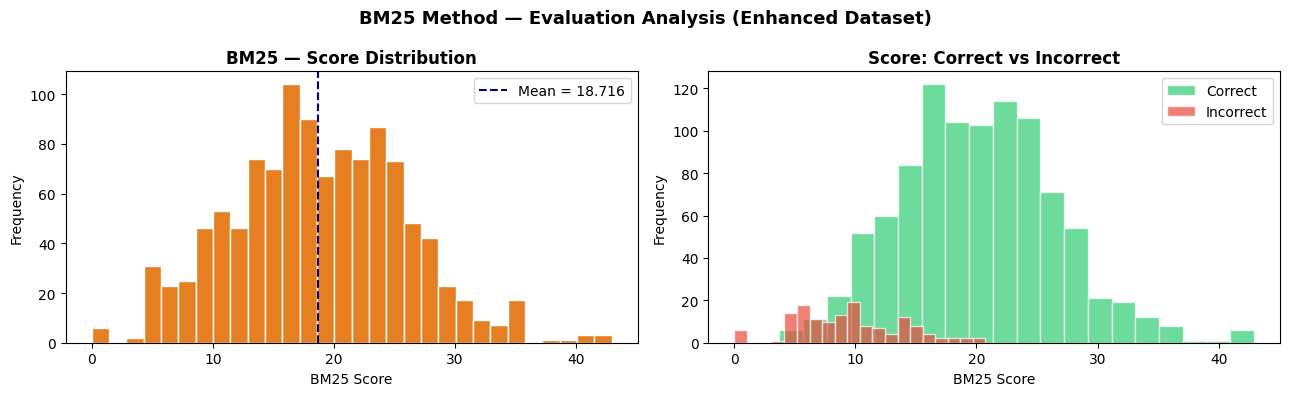

Plot saved ✅


In [10]:
scores_list      = metrics['details']['scores']
correct_list     = metrics['details']['correct_at1']
correct_scores   = [s for s, c in zip(scores_list, correct_list) if c]
incorrect_scores = [s for s, c in zip(scores_list, correct_list) if not c]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(scores_list, bins=30, color='#e67e22', edgecolor='white')
axes[0].axvline(np.mean(scores_list), color='navy', linestyle='--',
                label=f'Mean = {np.mean(scores_list):.3f}')
axes[0].set_title('BM25 — Score Distribution', fontweight='bold')
axes[0].set_xlabel('BM25 Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(correct_scores,   bins=20, alpha=0.7,
             color='#2ecc71', edgecolor='white', label='Correct')
axes[1].hist(incorrect_scores, bins=20, alpha=0.7,
             color='#e74c3c', edgecolor='white', label='Incorrect')
axes[1].set_title('Score: Correct vs Incorrect', fontweight='bold')
axes[1].set_xlabel('BM25 Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('BM25 Method — Evaluation Analysis (Enhanced Dataset)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join(RESULT_DIR, 'bm25_score_distribution.png'), dpi=150)
plt.show()
print('Plot saved ✅')

## Cell 11 — Error Analysis

In [11]:
errors = []
for _, row in df_test.iterrows():
    query       = row['query']
    true_answer = row['answer']
    answer, score, matched_q, _ = retrieve_bm25(query, bm25, df_index)
    if answer.strip() != true_answer.strip():
        errors.append({
            'query'      : query,
            'matched_q'  : matched_q,
            'score'      : round(score, 4),
            'true_answer': true_answer[:60],
            'pred_answer': answer[:60],
        })

errors_df = pd.DataFrame(errors)
print(f'Total errors : {len(errors_df)} / {len(df_test)}')
print(f'Error rate   : {len(errors_df)/len(df_test)*100:.1f}%')
if len(errors_df) > 0:
    print('\nSample errors:')
    display(errors_df.head(5)[['query', 'matched_q', 'score']])

Total errors : 143 / 1120
Error rate   : 12.8%

Sample errors:


,query,matched_q,score
0,ما الغرض الذي أُسست من أجله كلية الاقتصاد والأ...,من هو عميد كلية الاقتصاد والأعمال؟,12.4098
1,ما الأقسام التي تضمها كلية الاقتصاد والأعمال؟,كم عدد الأقسام في كلية الاقتصاد والأعمال؟,14.2666
2,ما الغرض من تخصص إدارة اللوجستيات؟,ما الغاية من دراسة تخصص إدارة اللوجستيات؟,11.1265
3,ما الغاية من دراسة تخصص إدارة اللوجستيات؟,ما الغاية من دراسة تخصص إدارة اللوجستيات؟,16.4367
4,لماذا يُقدَّم دراسة تخصص إدارة اللوجستيات؟,ما الغاية من دراسة تخصص إدارة اللوجستيات؟,11.1060


## Cell 12 — Save Results

In [12]:
metrics_df = pd.DataFrame([{
    'Method'       : 'BM25',
    'Accuracy@1'   : round(metrics['Accuracy@1'], 2),
    'Accuracy@3'   : round(metrics['Accuracy@3'], 2),
    'MRR'          : round(metrics['MRR'], 4),
    'Avg Score'    : round(metrics['Avg Score'], 4),
    'Avg Time (ms)': round(metrics['Avg Time (ms)'], 2),
    'Index Size'   : len(df_index),
    'Test Queries' : len(df_test),
}])
metrics_df.to_csv(
    os.path.join(RESULT_DIR, 'bm25_results.csv'), index=False)

print('='*50)
print('  SAVED')
print('='*50)
print(f'  results/bm25_results.csv')
print(f'  results/bm25_score_distribution.png')
print('='*50)
display(metrics_df)
print(f'\nNext → paste results into notebook 05 comparison')

  SAVED
  results/bm25_results.csv
  results/bm25_score_distribution.png


,Method,Accuracy@1,Accuracy@3,MRR,Avg Score,Avg Time (ms),Index Size,Test Queries
0,BM25,87.23,94.11,0.9064,18.7159,0.49,280,1120



Next → paste results into notebook 05 comparison
